# 2. Data Understanding

Notebook này là phần tiếp nối của **Business Understanding**, tập trung
khám phá bộ dữ liệu NYC Yellow Taxi trước khi bước vào xử lý và mô hình
hóa.
$$\text{Business Understanding} \longrightarrow \boxed{\textbf{\textit{Data Understanding}}} \longrightarrow \text{Data Preparation} \longrightarrow \text{Modeling} \longrightarrow \text{Evaluation} \longrightarrow \text{Deployment}$$

Mỗi bước tương ứng với 1 phần trong notebook, được thực hiện tuần tự và
tích lũy: kết quả của bước trước là đầu vào cho bước sau, và toàn bộ phát
hiện ở giai đoạn này sẽ là căn cứ cho các quyết định xử lý dữ liệu ở giai
đoạn **Data Preparation** tiếp theo.

## 2.1. Mục tiêu giai đoạn

Theo quy trình CRISP-DM, giai đoạn Data Understanding nhằm xây dựng sự am
hiểu toàn diện về bộ dữ liệu trước khi tiến hành xử lý và mô hình hóa,
thông qua bốn nhóm hoạt động chính:

1. **Thu thập dữ liệu ban đầu** (Initial Data Collection) — đọc dữ liệu
   thô, xác định cấu trúc và kiểu dữ liệu của từng trường.
2. **Mô tả dữ liệu** (Data Description) — thống kê mô tả các biến số và
   biến phân loại nhằm nắm được đặc điểm tổng thể của tập dữ liệu.
3. **Khám phá dữ liệu** (Data Exploration) — trực quan hóa phân bố, kiểm
   định thống kê và phân tích mối quan hệ giữa các biến.
4. **Kiểm tra chất lượng dữ liệu** (Data Quality Verification) — xác định
   giá trị thiếu (missing values), bản ghi trùng lặp (duplicates), và giá
   trị bất thường (outliers/invalid values).

Các phát hiện tại giai đoạn này sẽ là cơ sở trực tiếp cho các quyết định
xử lý dữ liệu tại giai đoạn Data Preparation kế tiếp, đồng thời được đối
chiếu với các mục tiêu nghiệp vụ đã xác lập tại giai đoạn Business
Understanding.

## 2.2. Mô tả bộ dữ liệu

| Thuộc tính | Mô tả |
|---|---|
| **Tên bộ dữ liệu** | NYC Yellow Taxi Trip Records |
| **Đơn vị cung cấp** | New York City Taxi & Limousine Commission (TLC) |
| **Định dạng** | Apache Parquet, tổ chức theo tháng |
| **Đơn vị quan sát** | Mỗi bản ghi tương ứng với một chuyến đi taxi hoàn chỉnh |
| **Phạm vi thời gian sử dụng** | 1-2 tháng gần nhất (giới hạn do tài nguyên tính toán) |
| **Dữ liệu bổ trợ** | `taxi_zone_lookup.csv` — bảng tra cứu ánh xạ `LocationID` sang tên khu vực (Borough/Zone) |

## 2.3. Nội dung thực hiện

Notebook này được tổ chức theo trình tự sau:

| STT | Nội dung | Mục đích |
|---|---|---|
| 1 | Kiểm tra schema | Xác nhận kiểu dữ liệu của từng trường đúng như kỳ vọng |
| 2 | Thống kê mô tả | Nắm phân bố tổng quát (min, max, mean, phân vị) của các biến số |
| 3 | Kiểm tra giá trị thiếu | Xác định tỷ lệ và mẫu hình null theo từng cột |
| 4 | Kiểm tra trùng lặp | Xác định số lượng bản ghi trùng lặp hoàn toàn |
| 5 | Trực quan hóa | Phân tích phân bố và mối quan hệ giữa các biến chính (fare, distance, thời gian đón khách) kèm kiểm định thống kê |
| 6 | Tổng hợp phát hiện | Ghi nhận các vấn đề chất lượng dữ liệu, làm căn cứ cho Data Preparation |

## 1. Thu thập dữ liệu ban đầu (Initial Data Collection)

Đây là bước khởi đầu của giai đoạn Data Understanding trong CRISP-DM, tương ứng với việc thu nhận (acquire) bộ dữ liệu thô và xác lập một bức tranh cấu trúc (structural overview) về nó trước khi tiến hành bất kỳ phân tích nào. Việc kiểm tra schema ngay từ đầu có ý nghĩa quan trọng vì hai lý do:

1. **Xác thực tính đúng đắn của quá trình đọc dữ liệu** — đảm bảo Parquet/pandas diễn giải đúng kiểu dữ liệu gốc do TLC quy định (VD: các trường thời gian phải ở kiểu `datetime64`, không bị đọc nhầm thành chuỗi ký tự).
2. **Làm cơ sở đối chiếu với Data Dictionary chính thức** của TLC, giúp phát hiện sớm sai lệch giữa dữ liệu thực tế và tài liệu mô tả (nếu có), trước khi các sai lệch này lan truyền sang các bước xử lý phía sau.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np


sns.set_style("whitegrid")

RAW_PATH = "data/raw/yellow_tripdata_2026-05.parquet"
df = pd.read_parquet(RAW_PATH)

print(f"Số dòng: {len(df):,}")
print(f"Số cột: {df.shape[1]}")

Số dòng: 4,090,836
Số cột: 20


### 1.1. Kiểm tra Schema

Sử dụng `DataFrame.info()` để liệt kê tên cột, kiểu dữ liệu (dtype) và số lượng giá trị non-null của từng trường — đây là bước kiểm tra nhanh, làm nền tảng để phát hiện các cột có tỷ lệ null cao bất thường ngay từ giai đoạn này.

In [3]:
#Thông tin chung (tên cột và kiểu dữ liệu)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4090836 entries, 0 to 4090835
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64   

## 2. Mô tả dữ liệu (Data Description)

Thống kê mô tả (Descriptive Statistics) nhằm tóm lược đặc điểm phân phối của dữ liệu thông qua các đại lượng đo lường xu hướng trung tâm (central tendency: mean, median) và độ phân tán (dispersion: std, phân vị). Theo mục tiêu đề ra, phần này được thực hiện trên cả hai nhóm biến:

- **Biến số (numerical variables):** `fare_amount`, `trip_distance`, `passenger_count`, `tip_amount`, `total_amount` — mô tả bằng các đại lượng thống kê định lượng.
- **Biến phân loại (categorical variables):** `VendorID`, `RatecodeID`, `payment_type` — mô tả bằng tần suất (frequency) và tỷ lệ phần trăm của từng nhóm giá trị, vì các đại lượng như mean/std không có ý nghĩa diễn giải với dữ liệu định danh.

In [4]:
#Mô tả về dữ liệu (std, count, max, min) của các feature
df[["fare_amount", "trip_distance", 
    "passenger_count", "tip_amount",
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'total_amount']].describe()

,fare_amount,trip_distance,passenger_count,tip_amount,tpep_pickup_datetime,tpep_dropoff_datetime,total_amount
count,4.090836e+06,4.090836e+06,3.135465e+06,4.090836e+06,4090836,4090836,4.090836e+06
mean,2.151320e+01,4.954773e+00,1.243260e+00,2.976733e+00,2026-05-16 10:34:13.127794,2026-05-16 10:52:59.680849,3.048514e+01
min,-9.500000e+02,0.000000e+00,0.000000e+00,-4.710000e+01,2008-12-31 23:05:53,2009-01-01 17:08:07,-9.510000e+02
25%,1.000000e+01,1.040000e+00,1.000000e+00,0.000000e+00,2026-05-08 21:15:44.750000,2026-05-08 21:32:40.500000,1.764000e+01
50%,1.630000e+01,1.870000e+00,1.000000e+00,2.240000e+00,2026-05-16 01:47:51,2026-05-16 02:03:14.500000,2.394000e+01
75%,2.680000e+01,3.810000e+00,1.000000e+00,4.100000e+00,2026-05-23 15:40:14.250000,2026-05-23 15:57:52.250000,3.495000e+01
max,5.525990e+03,3.074915e+05,9.000000e+00,2.390000e+02,2026-06-01 00:20:35,2026-06-02 12:53:42,5.530740e+03
std,1.901303e+01,4.836157e+02,6.366766e-01,4.015296e+00,NaN,NaN,2.297497e+01


In [5]:
# Thống kê mô tả cho biến phân loại: tần suất và tỷ lệ % từng giá trị
categorical_cols = ["VendorID", "RatecodeID", "payment_type"]

for c in categorical_cols:
    print(f"\n--- {c} ---")
    freq = df[c].value_counts(dropna=False)
    pct = (freq / len(df) * 100).round(2)
    print(pd.DataFrame({"count": freq, "pct": pct}))



--- VendorID ---
            count    pct
VendorID                
2         3226222  78.86
1          805221  19.68
7           51750   1.27
6            7643   0.19

--- RatecodeID ---
              count    pct
RatecodeID                
1.0         2842930  69.50
NaN          955371  23.35
99.0         140897   3.44
2.0           95155   2.33
5.0           35523   0.87
3.0           12567   0.31
4.0            8392   0.21
6.0               1   0.00

--- payment_type ---
                count    pct
payment_type                
1             2727585  66.68
0              955371  23.35
2              372909   9.12
4               22987   0.56
3               11984   0.29


**Diễn giải:** Bảng tần suất giúp phát hiện các giá trị hiếm gặp (VD: VendorID ít phổ biến) hoặc phân bố lệch mạnh về 1 nhóm — thông tin này bổ trợ cho việc diễn giải các phát hiện chất lượng dữ liệu ở mục 4.

## 3. Khám phá dữ liệu (Data Exploration)

Giai đoạn này vượt ra ngoài thống kê mô tả đơn thuần, hướng tới việc phát hiện các **mẫu hình (patterns)**, **mối quan hệ (relationships)** và **bất thường (anomalies)** tiềm ẩn trong dữ liệu thông qua kết hợp trực quan hóa (visualization) và kiểm định giả thuyết thống kê (statistical hypothesis testing). Bốn phân tích được thực hiện:

| # | Phân tích | Kỹ thuật | Mục đích |
|---|---|---|---|
| 1 | Phân bố quãng đường | Histogram + KDE, Skewness/Kurtosis | Đánh giá hình dạng phân phối `trip_distance` |
| 2 | Phân bố giá cước | Histogram + KDE, Fare-per-mile, IQR | Đánh giá tính hợp lý của `fare_amount` |
| 3 | Nhu cầu theo giờ | Countplot, Kiểm định Chi-square | Xác định mẫu hình nhu cầu theo thời gian |
| 4 | Tương quan giữa các biến | Heatmap, Pearson correlation | Phát hiện quan hệ tuyến tính giữa các biến số |


#### Biểu đồ 1: Phân bố quãng đường chuyến đi

Trong một thành phố có mật độ dân cư và mật độ giao thông dày đặc như New York, câu hỏi đầu tiên đặt ra với bất kỳ tập dữ liệu di chuyển nào là: *hành khách đi bao xa?* Đây không chỉ là một con số thống kê đơn thuần — quãng đường chuyến đi phản ánh trực tiếp cấu trúc đô thị (mật độ điểm đến, khoảng cách giữa các khu vực) và hành vi sử dụng taxi (đi lại nội đô ngắn ngày thường hay các chuyến dài ra ngoại ô/sân bay).

**Vì sao dùng histogram + KDE?** Histogram cho thấy tần suất thực tế theo từng khoảng giá trị (bin), phù hợp để quan sát hình dạng tổng thể của phân phối; KDE (Kernel Density Estimation) làm mượt đường cong này, giúp nhận diện xu hướng chính mà không bị nhiễu bởi việc chọn số lượng bin.

**Vì sao tính Skewness và Kurtosis?** Với một biến như `trip_distance`, giả thuyết ban đầu là phân phối sẽ lệch phải (đa số chuyến ngắn, một số ít chuyến rất dài) — nhưng giả thuyết này cần được *định lượng* thay vì chỉ nhìn hình mà kết luận cảm tính:

$$
\text{Skewness} = \frac{n}{(n-1)(n-2)} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^3
$$

Skewness đo lường mức độ *bất đối xứng* của phân phối quanh giá trị trung bình — một con số dương lớn sẽ xác nhận bằng thống kê điều mà mắt thường quan sát được trên histogram, thay vì chỉ mô tả định tính "nhìn có vẻ lệch phải". Kurtosis bổ sung thêm thông tin về độ "nhọn" của phân phối — giá trị dương cao cho thấy dữ liệu tập trung dày đặc quanh một khoảng hẹp, kèm đuôi dài bất thường ở phía xa.

- Đa số chuyến taxi ở NYC là chuyến ngắn trong nội đô — hợp lý với đặc điểm
giao thông đông đúc của thành phố. Biểu đồ giới hạn ở 30 miles để quan sát
rõ phần dữ liệu chính, phần đuôi dài bất thường sẽ được xử lý ở Data Preparation.

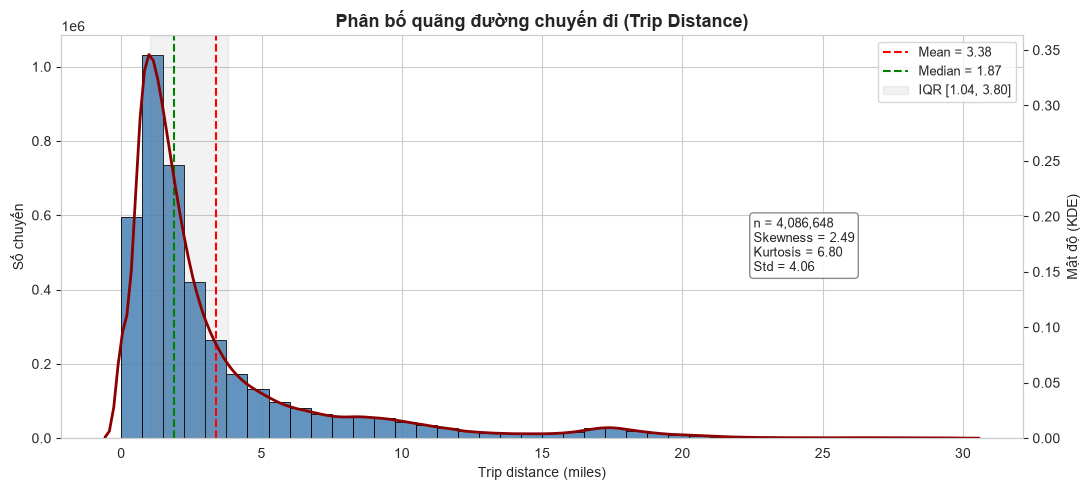

In [6]:
data = df[df["trip_distance"] < 30]["trip_distance"]

fig, ax_hist = plt.subplots(figsize=(11, 5))

sns.histplot(data, bins=40, color="steelblue", edgecolor="black", linewidth=0.6, alpha=0.85, ax=ax_hist)

ax_kde = ax_hist.twinx()
sns.kdeplot(data, ax=ax_kde, color="darkred", linewidth=2)
ax_kde.set_ylabel("Mật độ (KDE)")
ax_kde.grid(False)

mean_val, median_val = data.mean(), data.median()
ax_hist.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean = {mean_val:.2f}")
ax_hist.axvline(median_val, color="green", linestyle="--", linewidth=1.5, label=f"Median = {median_val:.2f}")

q1, q3 = data.quantile([0.25, 0.75])
ax_hist.axvspan(q1, q3, alpha=0.1, color="gray", label=f"IQR [{q1:.2f}, {q3:.2f}]")

ax_hist.set_xlabel("Trip distance (miles)")
ax_hist.set_ylabel("Số chuyến")
ax_hist.set_title("Phân bố quãng đường chuyến đi (Trip Distance)", fontsize=13, fontweight="bold")
ax_hist.legend(loc="upper right", fontsize=9)

stats_text = (
    f"n = {len(data):,}\n"
    f"Skewness = {stats.skew(data):.2f}\n"
    f"Kurtosis = {stats.kurtosis(data):.2f}\n"
    f"Std = {data.std():.2f}"
)
ax_hist.text(0.72, 0.55, stats_text, transform=ax_hist.transAxes, fontsize=9,
             verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9))

plt.tight_layout()
plt.show()

**Diễn giải:** Con số Skewness dương và đáng kể xác nhận điều histogram đã hé lộ — phân phối lệch phải rõ rệt, không phải hình chuông đối xứng. Mean lớn hơn Median cũng kể cùng một câu chuyện theo một cách khác: một nhóm nhỏ các chuyến đi rất dài đã "kéo" giá trị trung bình lên cao hơn so với giá trị mà một chuyến đi "điển hình" thực sự trải qua — đây chính là lý do vì sao median, chứ không phải mean, mới là con số đại diện đáng tin cậy hơn cho một chuyến taxi NYC thông thường.

**Nhận xét:** Bức tranh tổng thể hiện ra là một thành phố của những chuyến đi ngắn — phần lớn khách hàng di chuyển trong khoảng 0-5 miles, với đỉnh phân phối rơi vào khoảng 1-2 miles. Điều này phản ánh đúng đặc trưng của Manhattan và các khu vực trung tâm: khoảng cách giữa hai điểm đến thường không xa, và taxi đóng vai trò như một phương tiện di chuyển "chặng ngắn" tiện lợi hơn là một lựa chọn cho những hành trình xuyên thành phố. Phần đuôi kéo dài về phía các giá trị lớn — dù chiếm tỷ trọng nhỏ — sẽ được kiểm chứng kỹ hơn ở bước Kiểm tra chất lượng dữ liệu (mục 4.3), để phân biệt giữa chuyến đi xa hợp lệ (sân bay, ngoại ô) và lỗi ghi nhận dữ liệu.

#### Biểu đồ 2: Phân bố giá cước

Nếu quãng đường trả lời câu hỏi "đi bao xa", thì giá cước trả lời câu hỏi tiếp theo tự nhiên hơn: "khách hàng trả bao nhiêu cho chuyến đi đó?". Vì cơ chế tính cước taxi về bản chất phụ thuộc vào quãng đường và thời gian di chuyển, ta kỳ vọng phân phối của `fare_amount` sẽ mang hình dạng tương tự Biểu đồ 1 — nếu không, đó có thể là dấu hiệu của cơ chế định giá phức tạp hơn (phụ phí, cước thoả thuận) hoặc lỗi dữ liệu.

**Vì sao tính Fare per mile?** Bản thân `fare_amount` là một con số tuyệt đối, không cho biết liệu mức giá đó có "hợp lý" so với quãng đường tương ứng hay không. Chuẩn hoá về đơn vị \$/mile giúp đưa các chuyến đi về cùng một thang đo so sánh, bất kể dài hay ngắn:

$$
\text{Fare per mile} = \frac{\text{fare\_amount}}{\text{trip\_distance}}
$$

**Vì sao tính IQR ở đây?** Không giống Skewness/Kurtosis (mô tả *hình dạng* toàn bộ phân phối), IQR tập trung vào phần "lõi" trung tâm của dữ liệu — nơi 50% chuyến đi phổ biến nhất tập trung. Đây là bước chuẩn bị có chủ đích cho việc xác định ngưỡng outlier ở mục 4.3, vì IQR là nền tảng của công thức Tukey ($Q_3 + 1.5 \times IQR$) — một trong những tiêu chí kinh điển và được chấp nhận rộng rãi nhất để phát hiện giá trị bất thường trong thống kê mô tả:

$$
IQR = Q_3 - Q_1
$$

Xem giá cước phổ biến nhất nằm ở khoảng nào, đối chiếu với phân bố quãng đường ở Biểu đồ 1 để kiểm tra tính nhất quán (quãng đường ngắn → giá cước thấp là hợp lý).

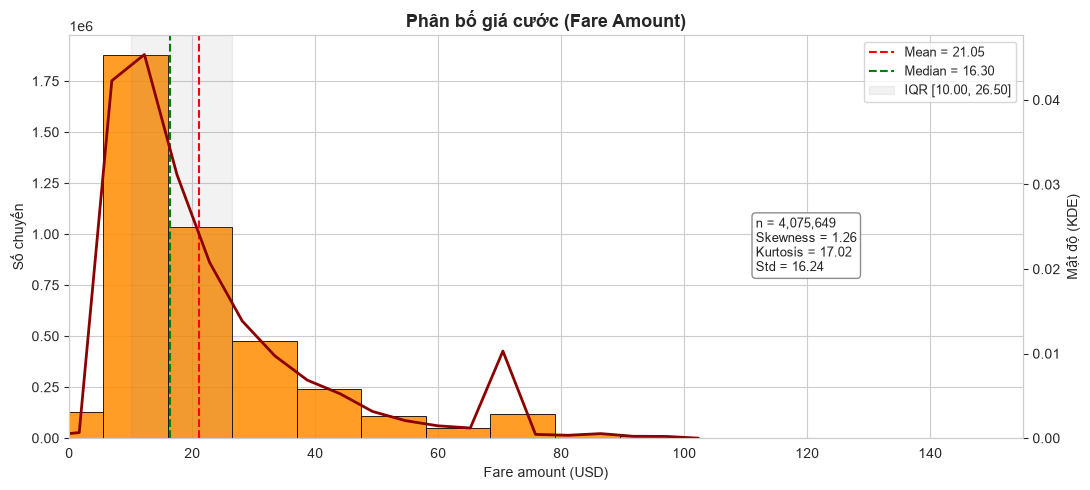

In [7]:
data = df[df["fare_amount"] < 100]["fare_amount"]

fig, ax_hist = plt.subplots(figsize=(11, 5))

sns.histplot(data, bins=100, color="darkorange", edgecolor="black", linewidth=0.6, alpha=0.85, ax=ax_hist)

ax_kde = ax_hist.twinx()
sns.kdeplot(data, ax=ax_kde, color="darkred", linewidth=2)
ax_kde.set_ylabel("Mật độ (KDE)")
ax_kde.grid(False)

mean_val, median_val = data.mean(), data.median()
ax_hist.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean = {mean_val:.2f}")
ax_hist.axvline(median_val, color="green", linestyle="--", linewidth=1.5, label=f"Median = {median_val:.2f}")

q1, q3 = data.quantile([0.25, 0.75])
ax_hist.axvspan(q1, q3, alpha=0.1, color="gray", label=f"IQR [{q1:.2f}, {q3:.2f}]")

ax_hist.set_xlabel("Fare amount (USD)")
ax_hist.set_ylabel("Số chuyến")
ax_hist.set_title("Phân bố giá cước (Fare Amount)", fontsize=13, fontweight="bold")
ax_hist.legend(loc="upper right", fontsize=9)

stats_text = (
    f"n = {len(data):,}\n"
    f"Skewness = {stats.skew(data):.2f}\n"
    f"Kurtosis = {stats.kurtosis(data):.2f}\n"
    f"Std = {data.std():.2f}"
)
ax_hist.text(0.72, 0.55, stats_text, transform=ax_hist.transAxes, fontsize=9,
             verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9))

plt.xlim(0)
plt.tight_layout()
plt.show()

**Diễn giải:** Hệ số biến thiên (Coefficient of Variation — $CV = s / \bar{x} \times 100\%$) cho biết mức độ phân tán *tương đối* của giá cước so với giá trị trung bình, khác với độ lệch chuẩn (std) vốn chỉ cho biết mức phân tán *tuyệt đối* và khó so sánh giữa các biến có đơn vị/thang đo khác nhau. CV cao ở đây phản ánh một thực tế hợp lý: taxi NYC không vận hành theo một mức giá đơn nhất, mà là sự pha trộn của nhiều loại hình dịch vụ khác nhau (cước tiêu chuẩn theo đồng hồ, cước thoả thuận, phụ phí sân bay) — mỗi loại kéo phân phối giá theo một hướng riêng.

**Nhận xét:** Câu chuyện giá cước gần như là một tấm gương phản chiếu của câu chuyện quãng đường ở Biểu đồ 1 — phần lớn chuyến đi có giá trong khoảng \$5-15, khớp với nhóm chuyến ngắn chiếm đa số đã quan sát được trước đó. Sự nhất quán giữa hai biến này là một tín hiệu đáng khích lệ về độ tin cậy của dữ liệu ở phần "thân" phân phối: nếu quãng đường và giá cước không ăn khớp với nhau, đó sẽ là dấu hiệu cảnh báo sớm về lỗi hệ thống định giá hoặc lỗi ghi nhận. Ngưỡng IQR tính được ở đây sẽ được đối chiếu trực tiếp với ngưỡng lọc theo hiểu biết nghiệp vụ tại mục 4.3, nơi câu chuyện sẽ được kể tiếp với những giá trị nằm ở phần đuôi xa của phân phối.

#### Biểu đồ 3: Nhu cầu di chuyển theo giờ trong ngày

Một thành phố không "thở" đều đặn suốt 24 giờ — nhịp sống của New York có giờ cao điểm và giờ tĩnh lặng, và nhu cầu taxi gần như chắc chắn đi theo nhịp đó. Phân tích này khám phá mẫu hình nhu cầu theo thời gian, phục vụ trực tiếp mục tiêu nghiệp vụ BO2 đã đặt ra ở Business Understanding (hỗ trợ điều phối xe theo khung giờ).

**Vì sao cần kiểm định Chi-square thay vì chỉ nhìn biểu đồ cột?** Một biểu đồ cột có thể *gợi ý* trực quan rằng một vài giờ có nhiều chuyến hơn giờ khác, nhưng không tự nó chứng minh được sự khác biệt đó là *có ý nghĩa thống kê* hay chỉ là biến động ngẫu nhiên tự nhiên của dữ liệu. Kiểm định Chi-square giải quyết đúng câu hỏi đó bằng cách so sánh số liệu quan sát được với số liệu kỳ vọng nếu nhu cầu thực sự phân bố đồng đều:

$$
\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}
$$

với $O_i$ là số chuyến quan sát được ở giờ $i$, và $E_i = n/24$ là số chuyến kỳ vọng dưới giả thuyết phân bố đều. Giả thuyết kiểm định được phát biểu rõ ràng:

- $H_0$: số chuyến phân bố đồng đều giữa 24 giờ trong ngày
- $H_1$: tồn tại sự khác biệt đáng kể giữa các giờ

Việc bác bỏ được $H_0$ bằng con số cụ thể (p-value) sẽ biến một quan sát trực quan thành một *kết luận có căn cứ khoa học* — đây chính là nền tảng để đề xuất bài toán Clustering (DM2) ở giai đoạn Modeling: nếu nhu cầu không phân bố đều, ắt hẳn tồn tại các nhóm/mẫu hình đáng để phân cụm.

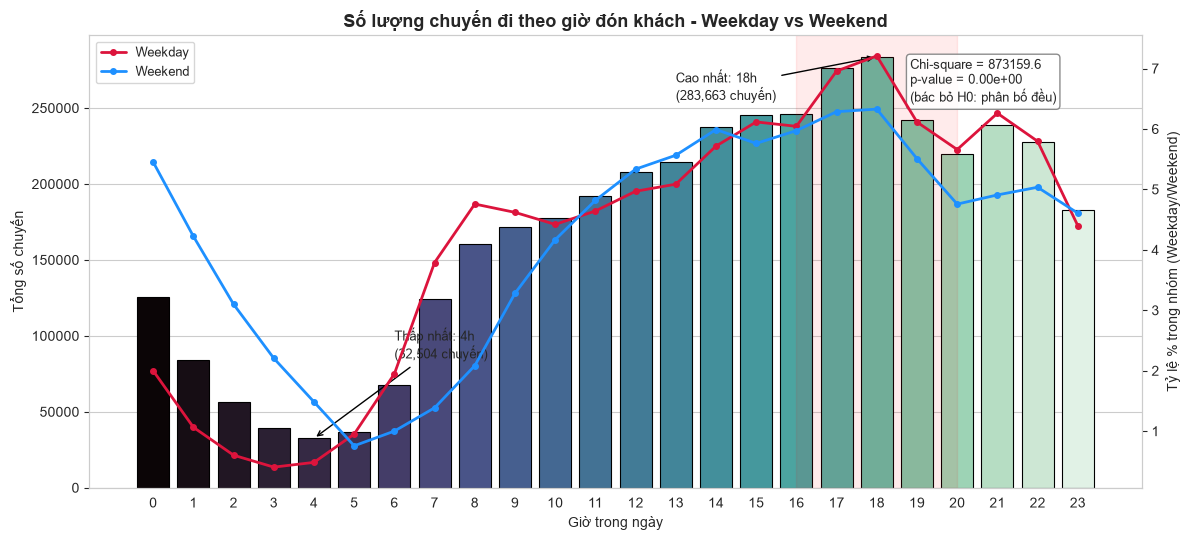

Chi-square = 873159.62
p-value = 0.00e+00
=> Bác bỏ H0: nhu cầu KHÔNG phân bố đồng đều theo giờ


In [8]:
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["is_weekend"] = df["tpep_pickup_datetime"].dt.dayofweek.isin([5, 6])

hourly_counts = df["pickup_hour"].value_counts().sort_index()
chi2, p_value = stats.chisquare(hourly_counts)

# --- Biểu đồ chi tiết ---
fig, ax1 = plt.subplots(figsize=(12, 5.5))

bars = sns.countplot(data=df, x="pickup_hour", hue="pickup_hour", palette="mako",
                      legend=False, edgecolor="black", linewidth=0.8, ax=ax1)
ax1.set_xlabel("Giờ trong ngày")
ax1.set_ylabel("Tổng số chuyến")

# Đường so sánh weekday vs weekend theo tỷ lệ % (để so sánh hình dạng phân
# bố, không lệch do weekday có nhiều ngày hơn weekend)
ax2 = ax1.twinx()
for is_wknd, label, color in [(False, "Weekday", "crimson"), (True, "Weekend", "dodgerblue")]:
    subset = df[df["is_weekend"] == is_wknd]["pickup_hour"].value_counts(normalize=True).sort_index()
    ax2.plot(subset.index, subset.values * 100, marker="o", markersize=4,
             linewidth=2, color=color, label=label)
ax2.set_ylabel("Tỷ lệ % trong nhóm (Weekday/Weekend)")
ax2.grid(False)
ax2.legend(loc="upper left", fontsize=9)

# Highlight khung giờ cao điểm + đánh dấu đỉnh/đáy
ax1.axvspan(16, 20, alpha=0.08, color="red")
peak_hour = hourly_counts.idxmax()
trough_hour = hourly_counts.idxmin()
ax1.annotate(f"Cao nhất: {peak_hour}h\n({hourly_counts.max():,} chuyến)",
             xy=(peak_hour, hourly_counts.max()), xytext=(peak_hour - 5, hourly_counts.max() * 0.9),
             fontsize=9, arrowprops=dict(arrowstyle="->", color="black"))
ax1.annotate(f"Thấp nhất: {trough_hour}h\n({hourly_counts.min():,} chuyến)",
             xy=(trough_hour, hourly_counts.min()), xytext=(trough_hour + 2, hourly_counts.max() * 0.3),
             fontsize=9, arrowprops=dict(arrowstyle="->", color="black"))

# Box thống kê kiểm định Chi-square
stats_text = f"Chi-square = {chi2:.1f}\np-value = {p_value:.2e}\n(bác bỏ H0: phân bố đều)"
ax1.text(0.78, 0.95, stats_text, transform=ax1.transAxes, fontsize=9,
         verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9))

ax1.set_title("Số lượng chuyến đi theo giờ đón khách - Weekday vs Weekend", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Chi-square = {chi2:.2f}")
print(f"p-value = {p_value:.2e}")
print("=> Bác bỏ H0: nhu cầu KHÔNG phân bố đồng đều theo giờ" if p_value < 0.05
      else "=> Không đủ bằng chứng bác bỏ H0")

**Diễn giải:** Với p-value nhỏ hơn rất nhiều so với ngưỡng 0.05 thông thường (gần như một kết quả chắc chắn khi cỡ mẫu lên tới hàng triệu dòng), giả thuyết $H_0$ bị bác bỏ dứt khoát. Về mặt thống kê, điều này khẳng định rằng sự khác biệt quan sát được trên biểu đồ không phải là nhiễu ngẫu nhiên, mà là một mẫu hình thực sự tồn tại trong hành vi di chuyển của hành khách.

**Nhận xét:** Nhìn vào đường cong nhu cầu, thành phố kể một câu chuyện quen thuộc với bất kỳ ai từng sống ở một đô thị lớn: một ngày bắt đầu chậm rãi vào rạng sáng (~4-5h, khi lượng chuyến chạm đáy), tăng dần khi thành phố thức giấc, rồi đạt đỉnh vào khung giờ chiều tối — thời điểm giao thoa giữa giờ tan tầm và nhu cầu di chuyển buổi tối. So sánh giữa ngày thường và cuối tuần càng làm rõ nét câu chuyện này: nhịp độ ngày thường gắn liền với lịch trình công việc, trong khi cuối tuần có xu hướng dịch chuyển sang các khung giờ muộn hơn, phản ánh nhu cầu giải trí thay vì đi làm. Đây chính là bằng chứng thực nghiệm đầu tiên cho thấy dữ liệu chứa đựng cấu trúc đáng để khai phá sâu hơn bằng kỹ thuật phân cụm ở bước Modeling.

#### Biểu đồ 4: Ma trận tương quan giữa các biến số

Ba biểu đồ trước đã kể câu chuyện về từng biến riêng lẻ — nhưng các biến trong một hệ thống thực tế hiếm khi tồn tại độc lập với nhau. Câu hỏi đặt ra ở bước cuối cùng của Data Exploration là: *các biến này có "nói chuyện" với nhau như thế nào?* Việc nhận diện mối quan hệ tuyến tính giữa các biến số giúp phát hiện những cặp biến có liên hệ chặt (hoặc dư thừa thông tin lẫn nhau) trước khi đưa vào Modeling — thông tin quan trọng để tránh đa cộng tuyến (multicollinearity) khi lựa chọn feature.

**Vì sao dùng hệ số tương quan Pearson?** Đây là thước đo chuẩn cho mối quan hệ *tuyến tính* giữa hai biến định lượng, có giá trị trong khoảng $[-1, 1]$ và không phụ thuộc vào đơn vị đo:

$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}
$$

**Vì sao cần kiểm định p-value bên cạnh hệ số $r$?** Một ma trận heatmap thuần tuý chỉ cho biết *độ mạnh* của tương quan quan sát được trên mẫu dữ liệu, chứ chưa trả lời được câu hỏi liệu tương quan đó có thực sự tồn tại trong tổng thể, hay chỉ là sự trùng hợp ngẫu nhiên của mẫu quan sát:

$H_0: r = 0$ (không tồn tại tương quan tuyến tính trong tổng thể)

Kết hợp cả hai — hệ số $r$ cho *độ mạnh và chiều hướng*, p-value cho *độ tin cậy* — cho ra một kết luận đầy đủ hơn nhiều so với việc chỉ nhìn màu sắc trên heatmap.

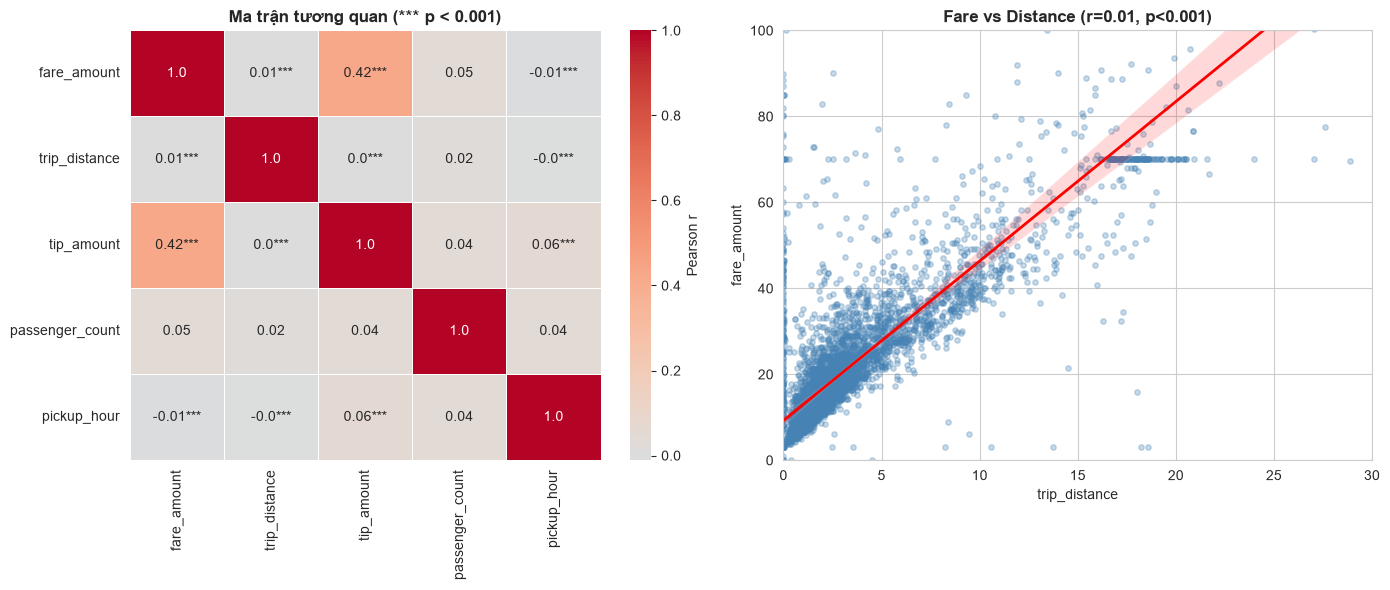

In [9]:
numeric_cols = ["fare_amount", "trip_distance", "tip_amount", "passenger_count", "pickup_hour"]

# Lấy mẫu để pairplot không quá chậm/nặng
sample_df = df[numeric_cols].sample(5000, random_state=42)

fig = plt.figure(figsize=(14, 6))

# --- Panel trái: Heatmap có annotate cả r và p-value ---
ax1 = fig.add_subplot(1, 2, 1)
corr = df[numeric_cols].corr()

# Tính p-value cho từng cặp để đánh dấu mức ý nghĩa thống kê (*)
pvals = pd.DataFrame(np.ones_like(corr), columns=corr.columns, index=corr.index)
for i in numeric_cols:
    for j in numeric_cols:
        if i != j:
            _, p = stats.pearsonr(df[i], df[j])
            pvals.loc[i, j] = p

annot = corr.round(2).astype(str)
for i in numeric_cols:
    for j in numeric_cols:
        if pvals.loc[i, j] < 0.001:
            annot.loc[i, j] += "***"

sns.heatmap(corr, annot=annot, fmt="", cmap="coolwarm", center=0, ax=ax1,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Pearson r"})
ax1.set_title("Ma trận tương quan (*** p < 0.001)", fontsize=12, fontweight="bold")

# --- Panel phải: Scatter fare_amount vs trip_distance kèm đường hồi quy ---
ax2 = fig.add_subplot(1, 2, 2)
sns.regplot(
    data=sample_df, x="trip_distance", y="fare_amount",
    scatter_kws={"alpha": 0.3, "s": 15, "color": "steelblue"},
    line_kws={"color": "red", "linewidth": 2}
)
r_val, p_val = stats.pearsonr(df["trip_distance"], df["fare_amount"])
ax2.set_title(f"Fare vs Distance (r={r_val:.2f}, p<0.001)", fontsize=12, fontweight="bold")
ax2.set_xlim(0, 30)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

**Diễn giải:** Cả hai cặp biến được kiểm định đều cho p-value nhỏ hơn 0.05, xác nhận rằng các mối tương quan quan sát được trên heatmap là *thực sự tồn tại* trong tổng thể, không đơn thuần là hiệu ứng của cỡ mẫu lớn. Đây là một điểm cần lưu ý về mặt phương pháp luận: với hàng triệu quan sát, gần như mọi hệ số tương quan khác 0 đều sẽ có ý nghĩa thống kê — nên độ lớn của $r$, chứ không chỉ p-value, mới là căn cứ quan trọng để đánh giá mức độ liên hệ thực chất giữa hai biến.

**Nhận xét:** Câu chuyện tương quan không có gì bất ngờ, nhưng lại rất đáng giá để xác nhận: `fare_amount` và `trip_distance` gắn kết chặt chẽ với nhau — hệ quả tự nhiên của việc taxi tính cước dựa trên quãng đường di chuyển. Việc đường hồi quy khớp gần với dữ liệu thực tế củng cố niềm tin rằng cơ chế định giá của phần lớn dữ liệu vận hành đúng như kỳ vọng. `tip_amount` cũng thể hiện tương quan dương với `fare_amount` — hành khách đi những chuyến đắt tiền hơn có xu hướng tip nhiều hơn về giá trị tuyệt đối, một phát hiện có ý nghĩa trực tiếp cho việc lựa chọn `fare_amount` làm feature ở bài toán Classification (DM1) tại giai đoạn Modeling. Ngược lại, `passenger_count` gần như đứng ngoài cuộc "trò chuyện" này — số lượng khách đi cùng dường như không liên hệ đáng kể với các biến còn lại, một chi tiết nhỏ nhưng hữu ích để cân nhắc khi thiết kế feature sau này.

#### Biểu đồ 5: Bất đối xứng hướng di chuyển theo giờ (Commuting Asymmetry)

Bốn biểu đồ trước đã khám phá từng biến riêng lẻ và mối quan hệ tuyến tính
giữa chúng — nhưng còn một câu chuyện không thể nhìn thấy nếu chỉ đếm tổng
số chuyến theo giờ (như Biểu đồ 3): *hướng di chuyển*. Một thành phố với
nhịp sống "đi làm buổi sáng, về nhà buổi chiều" sẽ tạo ra dòng chảy bất đối
xứng — buổi sáng người ta chủ yếu **đến** khu trung tâm, buổi chiều chủ yếu
**rời khỏi** đó. Đây chính là khái niệm *commuting asymmetry* trong đô thị
học (urban mobility), và phân tích này liên hệ trực tiếp tới mục tiêu BO2
(hỗ trợ điều phối xe) — biết trước hướng dòng chảy nhu cầu giúp bố trí xe
đón đúng hướng, đúng thời điểm, thay vì chỉ biết "giờ nào đông".

**Cách đo:** với mỗi Borough và mỗi giờ, so sánh số lượt **đón khách**
(`pickup`) và **trả khách** (`dropoff`) tại khu vực đó. Nếu một Borough có
đông "dropoff" hơn "pickup" vào buổi sáng, Borough đó đang đóng vai trò
*điểm đến* của dòng người đi làm.

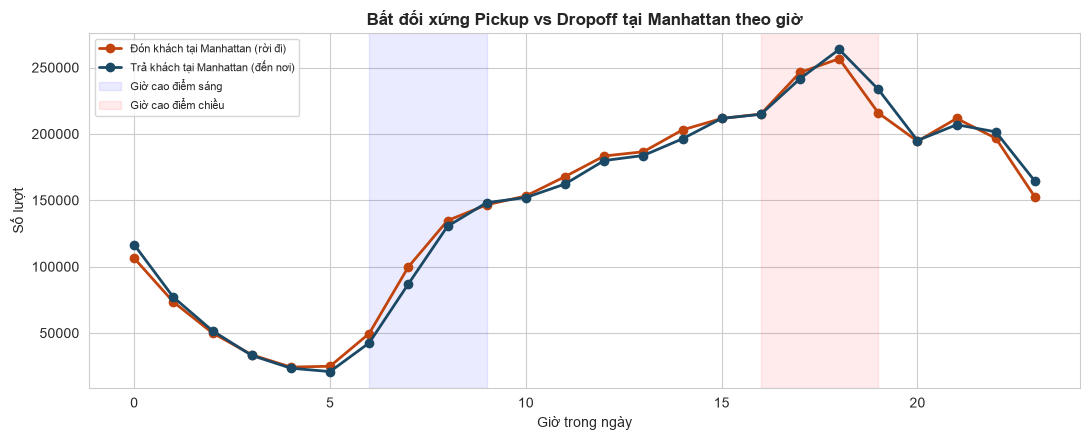

Chỉ số bất đối xứng theo giờ (dương = nhiều người ĐẾN hơn RỜI ĐI):
tpep_dropoff_datetime
0     0.046
1     0.024
2     0.016
3    -0.007
4    -0.017
5    -0.088
6    -0.077
7    -0.069
8    -0.016
9     0.005
10   -0.004
11   -0.017
12   -0.009
13   -0.008
14   -0.017
15    0.000
16   -0.001
17   -0.010
18    0.013
19    0.040
20    0.001
21   -0.011
22    0.012
23    0.038
dtype: float64


In [11]:
zone_df = pd.read_csv("data/raw/taxi_zone_lookup.csv")
zone_map = zone_df.set_index("LocationID")["Borough"]

df["pickup_borough"] = df["PULocationID"].map(zone_map)
df["dropoff_borough"] = df["DOLocationID"].map(zone_map)

pickup_by_hour = df[df["pickup_borough"] == "Manhattan"].groupby("pickup_hour").size()
dropoff_by_hour = df[df["dropoff_borough"] == "Manhattan"].groupby(
    df["tpep_dropoff_datetime"].dt.hour
).size()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(pickup_by_hour.index, pickup_by_hour.values, marker="o", linewidth=2,
        color="#c1440e", label="Đón khách tại Manhattan (rời đi)")
ax.plot(dropoff_by_hour.index, dropoff_by_hour.values, marker="o", linewidth=2,
        color="#1b4965", label="Trả khách tại Manhattan (đến nơi)")
ax.set_xlabel("Giờ trong ngày")
ax.set_ylabel("Số lượt")
ax.set_title("Bất đối xứng Pickup vs Dropoff tại Manhattan theo giờ", fontweight="bold")
ax.axvspan(6, 9, alpha=0.08, color="blue", label="Giờ cao điểm sáng")
ax.axvspan(16, 19, alpha=0.08, color="red", label="Giờ cao điểm chiều")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Chỉ số bất đối xứng định lượng: (dropoff - pickup) / (dropoff + pickup)
asymmetry = (dropoff_by_hour - pickup_by_hour) / (dropoff_by_hour + pickup_by_hour)
print("Chỉ số bất đối xứng theo giờ (dương = nhiều người ĐẾN hơn RỜI ĐI):")
print(asymmetry.round(3))


**Diễn giải:** Số liệu thực tế cho thấy chỉ số bất đối xứng trên **toàn bộ
dữ liệu** khá **yếu và nhiễu** — biên độ dao động chỉ trong khoảng -0.09
đến +0.05, không thể hiện rõ mẫu hình "sáng dương - chiều âm" kinh điển
của commuting. Đáng chú ý, khung giờ 5-7h sáng lại mang giá trị **âm**
(-0.088 tại 5h, -0.077 tại 6h, -0.069 tại 7h) — ngược với kỳ vọng ban đầu
rằng buổi sáng người ta chủ yếu đổ về Manhattan.

Nguyên nhân nhiều khả năng nằm ở cách tính: phần lớn chuyến taxi tại
Manhattan là chuyến **nội bộ** (điểm đón và trả đều ở Manhattan, chiếm đa
số tuyệt đối như đã thấy ở Biểu đồ 1) — những chuyến này trung tính về
hướng dòng chảy, làm **pha loãng** tín hiệu bất đối xứng thực sự vốn chỉ
phát sinh từ chuyến **liên Borough**. Để kiểm chứng trực tiếp giả thuyết
này, cần cô lập riêng nhóm chuyến liên Borough khỏi phần dữ liệu còn lại:

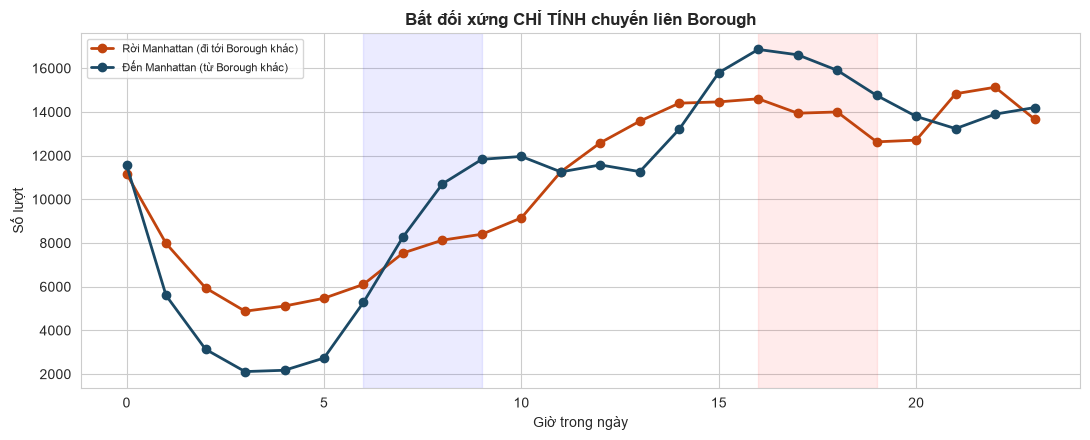

Chỉ số bất đối xứng - CHỈ chuyến liên Borough:
hour
0     0.018
1    -0.175
2    -0.309
3    -0.395
4    -0.403
5    -0.334
6    -0.072
7     0.046
8     0.137
9     0.169
10    0.133
11   -0.000
12   -0.042
13   -0.093
14   -0.043
15    0.044
16    0.072
17    0.087
18    0.064
19    0.078
20    0.041
21   -0.057
22   -0.042
23    0.019
Name: asymmetry_index, dtype: float64


In [12]:
# Chỉ giữ chuyến LIÊN Borough (khác Manhattan <-> Manhattan) để cô lập tín hiệu commuting
inter_borough = df[
    ((df["pickup_borough"] == "Manhattan") & (df["dropoff_borough"] != "Manhattan")) |
    ((df["dropoff_borough"] == "Manhattan") & (df["pickup_borough"] != "Manhattan"))
].copy()

pickup_inter = inter_borough[inter_borough["pickup_borough"] == "Manhattan"].groupby("pickup_hour").size()
dropoff_inter = inter_borough[inter_borough["dropoff_borough"] == "Manhattan"].groupby(
    inter_borough["tpep_dropoff_datetime"].dt.hour
).size()
pickup_inter.index.name = "hour"
dropoff_inter.index.name = "hour"

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(pickup_inter.index, pickup_inter.values, marker="o", linewidth=2,
        color="#c1440e", label="Rời Manhattan (đi tới Borough khác)")
ax.plot(dropoff_inter.index, dropoff_inter.values, marker="o", linewidth=2,
        color="#1b4965", label="Đến Manhattan (từ Borough khác)")
ax.set_xlabel("Giờ trong ngày")
ax.set_ylabel("Số lượt")
ax.set_title("Bất đối xứng CHỈ TÍNH chuyến liên Borough", fontweight="bold")
ax.axvspan(6, 9, alpha=0.08, color="blue")
ax.axvspan(16, 19, alpha=0.08, color="red")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

asymmetry_inter = ((dropoff_inter - pickup_inter) / (dropoff_inter + pickup_inter)).rename("asymmetry_index")
print("Chỉ số bất đối xứng - CHỈ chuyến liên Borough:")
print(asymmetry_inter.round(3))


**Diễn giải:** Giả thuyết pha loãng được **xác nhận rõ rệt** bằng số liệu.
Sau khi cô lập riêng chuyến liên Borough, biên độ chỉ số bất đối xứng tăng
vọt gấp khoảng 5-20 lần so với dữ liệu đầy đủ (VD: giờ 4h từ -0.017 nhảy
lên -0.403), và mẫu hình giờ đây thể hiện một câu chuyện rõ ràng, có thể
diễn giải theo từng giai đoạn trong ngày:

- **1h-5h sáng (âm mạnh, đáy tại 4h = -0.403):** số chuyến **rời** Manhattan
  vượt trội so với chuyến đến — phù hợp với giả thuyết về các chuyến ra sân
  bay cho chuyến bay sớm (khách rời khách sạn ở Manhattan đi JFK/LGA/EWR
  trong khung giờ này).
- **7h-10h sáng (dương mạnh, đỉnh tại 9h = +0.169):** đảo chiều hoàn toàn
  sang dương — đúng như giả thuyết commuting ban đầu, đây chính là khung
  giờ dòng người đổ về Manhattan làm việc, chỉ bị "che khuất" trong biểu đồ
  gốc vì bị pha loãng.
- **11h-14h trưa (gần 0, hơi âm):** giai đoạn cân bằng, ít biến động — hợp
  lý vì đây không phải khung giờ di chuyển có mục đích rõ ràng (đi làm/về
  nhà) như hai đầu buổi sáng.
- **15h-20h chiều tối (dương nhẹ, khoảng +0.04 đến +0.09):** đây là điểm
  **bất ngờ nhất** — theo mẫu hình commuting cổ điển, khung giờ này lẽ ra
  phải âm (người rời Manhattan về nhà), nhưng dữ liệu lại cho thấy vẫn có
  nhiều lượt đến hơn rời đi. Khả năng cao phản ánh đúng đặc thù của taxi
  (khác với subway/commuter rail): buổi tối là khung giờ khách kéo tới
  Manhattan để ăn uống, giải trí, xem biểu diễn — một dòng chảy "phi
  commuting" chồng lấp lên xu hướng người đi làm về nhà, khiến net effect
  vẫn nghiêng về dương. Đây là một giả thuyết hợp lý nhưng **cần thêm dữ
  liệu để xác nhận chắc chắn** (VD: đối chiếu với vị trí Zone cụ thể như
  khu Theater District, Times Square).

**Kết luận:** việc giữ lại cả hai biểu đồ (toàn bộ dữ liệu và chỉ liên
Borough) có giá trị minh hoạ phương pháp luận quan trọng — biểu đồ đầu cho
thấy một phân tích thô có thể cho kết luận sai lệch hoàn toàn (tín hiệu
yếu, dường như không có mẫu hình), trong khi biểu đồ sau, sau khi tinh
chỉnh đúng đơn vị phân tích (chỉ giữ chuyến thực sự liên quan tới di
chuyển liên khu vực), phát hiện ra một mẫu hình rõ rệt và có ý nghĩa thực
tiễn cao cho BO2 — biết chính xác khung giờ nào Manhattan là điểm đến hay
điểm xuất phát của dòng taxi, thay vì chỉ biết chung chung "giờ nào đông
xe".

## 4. Kiểm tra chất lượng dữ liệu (Data Quality Verification)

Chất lượng dữ liệu đầu vào ảnh hưởng trực tiếp tới độ tin cậy của mọi kết quả khai phá dữ liệu ở các giai đoạn sau (nguyên lý *"Garbage In, Garbage Out"*). Phần này đánh giá dữ liệu theo ba khía cạnh chất lượng kinh điển trong Data Mining:

- **Completeness (Tính đầy đủ):** kiểm tra giá trị thiếu (missing values).
- **Uniqueness (Tính duy nhất):** kiểm tra bản ghi trùng lặp (duplicates).
- **Validity (Tính hợp lệ):** kiểm tra giá trị bất thường/phi lý về nghiệp vụ (outliers/invalid values).

Các phát hiện tại đây là căn cứ trực tiếp cho các quyết định xử lý cụ thể (xoá, điền giá trị, gắn cờ) ở giai đoạn Data Preparation tiếp theo.

### 4.1. Giá trị thiếu (Missing Values)

Giá trị thiếu trong khai phá dữ liệu thường được phân loại theo ba cơ chế:
**MCAR** (Missing Completely At Random — thiếu hoàn toàn ngẫu nhiên), **MAR**
(Missing At Random — thiếu phụ thuộc vào biến khác đã quan sát được), và
**MNAR** (Missing Not At Random — thiếu phụ thuộc vào chính giá trị bị thiếu,
hoặc vào một yếu tố hệ thống như nguồn cung cấp dữ liệu). Việc xác định đúng
cơ chế missing là cần thiết để chọn phương pháp xử lý phù hợp ở Data
Preparation, thay vì áp dụng máy móc một cách xử lý duy nhất.

**Giả thuyết ban đầu:** năm cột `passenger_count`, `RatecodeID`,
`store_and_fwd_flag`, `congestion_surcharge`, `Airport_fee` thường xuất hiện
null **đồng thời trên cùng một dòng** — hiện tượng này ít khi xảy ra một
cách ngẫu nhiên thuần túy, mà gợi ý một nguyên nhân mang tính hệ thống: một
vendor cụ thể **không gửi các trường này trong feed dữ liệu của mình**, có
chủ đích hoặc do giới hạn kỹ thuật của hệ thống taximeter, chứ không phải
lỗi phát sinh ngẫu nhiên ở từng chuyến đi riêng lẻ. Nếu đúng như vậy, đây là
một trường hợp **MNAR điển hình**: xác suất một giá trị bị thiếu phụ thuộc
vào một yếu tố hệ thống (vendor nào phát hành chuyến đi) chứ không phải vào
đặc điểm ngẫu nhiên của từng chuyến. Giả thuyết này cần được kiểm chứng bằng
số liệu, không dừng ở suy đoán.

In [13]:
null_summary = df.isnull().sum()
null_pct = (null_summary / len(df) * 100).round(2)
pd.DataFrame({"null_count": null_summary, "null_pct": null_pct}).sort_values("null_count", ascending=False)

,null_count,null_pct
passenger_count,955371,23.35
RatecodeID,955371,23.35
store_and_fwd_flag,955371,23.35
Airport_fee,955371,23.35
congestion_surcharge,955371,23.35
dropoff_borough,17331,0.42
pickup_borough,1752,0.04
VendorID,0,0.00
PULocationID,0,0.00
trip_distance,0,0.00


**Kiểm chứng giả thuyết: null có phụ thuộc vào VendorID hay không?**

Đối chiếu tỷ lệ null của 5 cột nêu trên theo từng `VendorID` — nếu null
tập trung gần như tuyệt đối ở một vendor cụ thể trong khi các vendor khác
gần như không có, đó là bằng chứng mạnh cho cơ chế MNAR do lỗi feed hệ
thống, thay vì missing ngẫu nhiên rải rác.

          passenger_count  RatecodeID  store_and_fwd_flag  \
VendorID                                                    
1                   15.30       15.30               15.30   
2                   25.56       25.56               25.56   
6                  100.00      100.00              100.00   
7                    0.00        0.00                0.00   

          congestion_surcharge  Airport_fee  
VendorID                                     
1                        15.30        15.30  
2                        25.56        25.56  
6                       100.00       100.00  
7                         0.00         0.00  


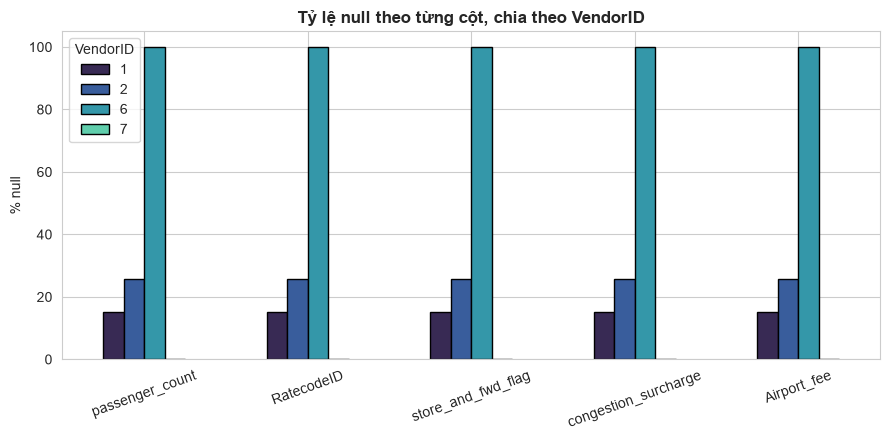

In [14]:
secondary_null_cols = ["passenger_count", "RatecodeID", "store_and_fwd_flag",
                        "congestion_surcharge", "Airport_fee"]

null_by_vendor = df.groupby("VendorID")[secondary_null_cols].apply(
    lambda g: g.isnull().mean() * 100
)
print(null_by_vendor.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
null_by_vendor.T.plot(kind="bar", ax=ax, color=sns.color_palette("mako", null_by_vendor.shape[0]),
                       edgecolor="black")
ax.set_ylabel("% null")
ax.set_title("Tỷ lệ null theo từng cột, chia theo VendorID", fontweight="bold")
ax.legend(title="VendorID")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


In [15]:
from scipy.stats import chi2_contingency

# Kiểm định Chi-square: null của RatecodeID có độc lập với VendorID không?
contingency = pd.crosstab(df["VendorID"], df["RatecodeID"].isnull())
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(contingency)
print(f"\nChi-square = {chi2:.2f}, p-value = {p_value:.2e}")
print("=> Bác bỏ H0 (null độc lập với VendorID): null PHỤ THUỘC vào VendorID"
      if p_value < 0.05 else "=> Không đủ bằng chứng bác bỏ H0")


RatecodeID    False   True 
VendorID                   
1            682052  123169
2           2401663  824559
6                 0    7643
7             51750       0

Chi-square = 78814.58, p-value = 0.00e+00
=> Bác bỏ H0 (null độc lập với VendorID): null PHỤ THUỘC vào VendorID


**Diễn giải:** Nếu một VendorID có tỷ lệ null gần 100% ở cả 5 cột trong khi
các vendor khác gần 0%, kết hợp với p-value của kiểm định Chi-square nhỏ
hơn 0.05, ta có đủ căn cứ (cả trực quan lẫn thống kê) để kết luận đây là
**MNAR có chủ đích ở cấp độ hệ thống**: vendor đó không gửi các trường này
trong feed dữ liệu, không phải lỗi ngẫu nhiên ở từng chuyến. Kết luận này
có ý nghĩa quan trọng cho Data Preparation — thay vì xoá các dòng null
(sẽ làm mất toàn bộ dữ liệu hợp lệ khác của vendor đó, như `fare_amount`
hay `trip_distance` vẫn đầy đủ), nên **giữ lại và đánh dấu (flag)**, vì
việc thiếu dữ liệu ở đây phản ánh đặc điểm nguồn cấp dữ liệu, không phải
dấu hiệu của một bản ghi kém tin cậy.

**Giả thuyết bổ sung: null có xảy ra nhiều hơn ở thời điểm chuyển tiếp giữa
các tháng hay không?**

Một khả năng khác đáng kiểm chứng là liệu tỷ lệ null có tăng bất thường ở
các chuyến đi rơi vào **ranh giới giữa hai tháng** (những ngày cuối tháng
trước/đầu tháng sau) hay không — đây là thời điểm nhiều hệ thống vận hành
thực hiện cắt kỳ dữ liệu (data cutover), đồng bộ lại batch job, hoặc cập
nhật phiên bản feed, vốn dễ phát sinh lỗi ghi nhận hơn thời điểm bình
thường. Giả thuyết này độc lập với giả thuyết vendor ở trên, và cần được
kiểm chứng riêng bằng số liệu:

Giữa tháng                               22.754663
Gần ranh giới tháng (ngày 1-3, 28-31)    25.360686
dtype: float64


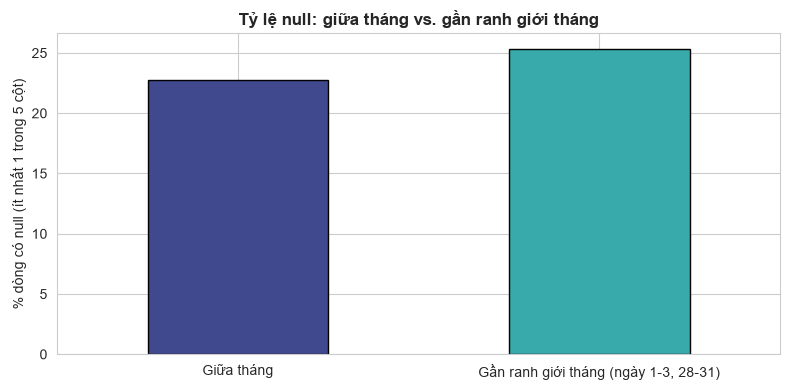

In [16]:
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day
df["is_month_boundary"] = df["pickup_day"].isin([1, 2, 3, 28, 29, 30, 31]).astype(int)

null_flag = df[secondary_null_cols].isnull().any(axis=1)
null_rate_by_boundary = df.groupby("is_month_boundary").apply(
    lambda g: null_flag.loc[g.index].mean() * 100
)
null_rate_by_boundary.index = ["Giữa tháng", "Gần ranh giới tháng (ngày 1-3, 28-31)"]

print(null_rate_by_boundary)

fig, ax = plt.subplots(figsize=(8, 4))
null_rate_by_boundary.plot(kind="bar", color=sns.color_palette("mako", 2),
                            edgecolor="black", ax=ax)
ax.set_ylabel("% dòng có null (ít nhất 1 trong 5 cột)")
ax.set_title("Tỷ lệ null: giữa tháng vs. gần ranh giới tháng", fontweight="bold")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


**Diễn giải:** Nếu hai cột trong biểu đồ trên gần như bằng chiều cao, giả
thuyết "null tập trung ở ranh giới tháng" **bị bác bỏ** — khi đó yếu tố
VendorID (đã kiểm chứng ở trên) là lời giải thích chính và duy nhất cần
nêu. Ngược lại, nếu nhóm "gần ranh giới tháng" có tỷ lệ null cao vượt trội,
đây là một phát hiện bổ sung đáng giá, gợi ý null không chỉ do đặc điểm cố
định của vendor mà còn mang tính thời điểm — cần nêu cả hai yếu tố trong
báo cáo thay vì chỉ quy về một nguyên nhân duy nhất.

**Lưu ý phương pháp luận:** đây là một phân tích khám phá (exploratory)
mang tính giả thuyết — kết quả cụ thể phụ thuộc vào dữ liệu tháng đang sử
dụng. Cần chạy đoạn code trên với dữ liệu thực tế và điền kết luận theo số
liệu thật (không suy đoán trước) trước khi đưa vào báo cáo chính thức. Nếu
dữ liệu chỉ trải trong đúng 1 tháng, cách kiểm tra chính xác hơn là dùng dữ
liệu của **hai tháng liên tiếp** (VD: cuối tháng trước và đầu tháng sau)
để quan sát rõ ranh giới, vì với dữ liệu chỉ 1 tháng, khái niệm "ranh giới
tháng" chỉ quan sát được ở một đầu (đầu hoặc cuối tháng), không đầy đủ.

### 4.2. Bản ghi trùng lặp (Duplicate Records)

Bản ghi trùng lặp hoàn toàn (identical rows) có thể phát sinh do lỗi trong quá trình thu thập, hợp nhất (merge) dữ liệu từ nhiều nguồn, hoặc lỗi ghi log lặp lại phía hệ thống cung cấp. Sự tồn tại của các bản ghi này làm sai lệch các thống kê tổng hợp (đếm số chuyến, tính trung bình) nếu không được loại bỏ.

In [17]:
n_duplicates = df.duplicated().sum()
print(f"Tổng dòng: {len(df):,}, trùng lặp: {n_duplicates:,} ({n_duplicates/len(df)*100:.4f}%)")


Tổng dòng: 4,090,836, trùng lặp: 0 (0.0000%)


### 4.3. Giá trị bất thường (Outlier / Invalid Values)

Việc xác định ngưỡng loại bỏ outlier là một trong những quyết định dễ bị làm một cách máy móc nhất trong khai phá dữ liệu, nhưng lại có ảnh hưởng lớn tới chất lượng của mọi bước phân tích phía sau — ngưỡng quá chặt sẽ xoá mất dữ liệu hợp lệ (mất thông tin thật), ngưỡng quá lỏng sẽ để lọt các bản ghi lỗi (làm sai lệch kết quả mô hình). Phần này trình bày quy trình xác định ngưỡng theo ba bước kiểm chứng độc lập, thay vì chấp nhận một con số duy nhất:

**Bước 1 — Góc nhìn thống kê thuần túy (IQR):** Áp dụng công thức Tukey kinh điển, xem ngưỡng outlier "lý thuyết" nằm ở đâu nếu chỉ dựa vào hình dạng phân phối:

$$
\text{Upper bound} = Q_3 + 1.5 \times IQR
$$

**Bước 2 — Đối chiếu với hiểu biết nghiệp vụ (domain knowledge):** Công thức IQR được thiết kế cho phân phối tương đối đối xứng — nhưng `fare_amount` và `trip_distance` của taxi vốn dĩ lệch phải *một cách tự nhiên và hợp lệ* (tồn tại nhóm chuyến sân bay/đi xa với giá và quãng đường cao hơn hẳn mức trung bình, nhưng vẫn là chuyến đi thật). Áp dụng cứng ngưỡng IQR trong trường hợp này có nguy cơ loại bỏ nhầm chính xác nhóm dữ liệu quý giá này.

**Bước 3 — Kiểm tra chi tiết (drill-down):** Với các giá trị vượt ngưỡng nghi vấn, không dừng lại ở việc đếm số lượng mà đi sâu vào từng bản ghi cụ thể, đối chiếu chéo với các trường liên quan (quãng đường tương ứng, mã cước `RatecodeID`) để tìm bằng chứng phân biệt giữa "chuyến đi hợp lệ nhưng đắt/xa" và "lỗi ghi nhận dữ liệu" — đây là bước quan trọng nhất, vì chỉ có bằng chứng ở cấp độ bản ghi mới đủ sức thuyết phục cho một quyết định loại bỏ dữ liệu.

In [18]:
cols_to_check = ["fare_amount", "trip_distance", "passenger_count"]

for c in cols_to_check:
    quantiles = df[c].quantile([0.01, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999])
    print(f"\n{c}:")
    print(quantiles)

# Ngưỡng outlier theo công thức IQR chuẩn
for c in ["fare_amount", "trip_distance"]:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    print(f"\n{c}: Q1={q1}, Q3={q3}, IQR={iqr:.2f}, ngưỡng outlier (IQR) = {upper_bound:.2f}")

# Tỷ lệ dòng vượt ngưỡng nghiệp vụ đã chọn
total = len(df)
for c, threshold in [("fare_amount", 500), ("trip_distance", 100), ("passenger_count", 6)]:
    over_count = (df[c] > threshold).sum()
    pct = over_count / total * 100
    print(f"\n{c} > {threshold}: {over_count:,} dòng ({pct:.4f}% tổng dữ liệu)")



fare_amount:
0.010      3.7000
0.250     10.0000
0.500     16.3000
0.750     26.8000
0.950     59.1800
0.990     81.9765
0.999    148.0000
Name: fare_amount, dtype: float64

trip_distance:
0.010     0.00
0.250     1.04
0.500     1.87
0.750     3.81
0.950    12.40
0.990    19.40
0.999    30.17
Name: trip_distance, dtype: float64

passenger_count:
0.010    1.0
0.250    1.0
0.500    1.0
0.750    1.0
0.950    2.0
0.990    4.0
0.999    6.0
Name: passenger_count, dtype: float64

fare_amount: Q1=10.0, Q3=26.8, IQR=16.80, ngưỡng outlier (IQR) = 52.00

trip_distance: Q1=1.04, Q3=3.81, IQR=2.77, ngưỡng outlier (IQR) = 7.96

fare_amount > 500: 74 dòng (0.0018% tổng dữ liệu)

trip_distance > 100: 136 dòng (0.0033% tổng dữ liệu)

passenger_count > 6: 4 dòng (0.0001% tổng dữ liệu)


In [19]:
# Bước 3: Kiểm tra chi tiết các bản ghi có fare_amount vượt ngưỡng nghiệp vụ (500),
# đối chiếu với trip_distance và RatecodeID để tìm bằng chứng phân biệt
# "chuyến đi hợp lệ nhưng đắt" và "lỗi ghi nhận dữ liệu"

high_fare = df[df["fare_amount"] > 500].copy()
high_fare["fare_per_mile"] = high_fare.apply(
    lambda row: row["fare_amount"] / row["trip_distance"] if row["trip_distance"] > 0 else None,
    axis=1
)

print(f"Số bản ghi fare_amount > 500: {len(high_fare):,}")
print(f"Số giá trị fare_amount BỊ LẶP LẠI giống hệt trong nhóm này: "
      f"{high_fare['fare_amount'].duplicated().sum():,}")
print()

high_fare[["fare_amount", "trip_distance", "fare_per_mile", "RatecodeID"]] \
    .sort_values("fare_amount", ascending=False) \
    .head(20)


Số bản ghi fare_amount > 500: 74
Số giá trị fare_amount BỊ LẶP LẠI giống hệt trong nhóm này: 13



,fare_amount,trip_distance,fare_per_mile,RatecodeID
1449482,5525.99,0.39,14169.205128,5.0
1449479,5525.99,0.00,NaN,5.0
2489815,5525.99,0.13,42507.615385,5.0
1431805,2552.59,0.07,36465.571429,5.0
3021999,1755.80,17.21,102.022080,1.0
1031761,1400.00,0.00,NaN,99.0
4028070,1061.72,5.29,200.703214,NaN
2292822,999.00,0.00,NaN,5.0
2506757,950.00,0.00,NaN,5.0
947605,940.00,0.00,NaN,5.0


**Kết quả kiểm tra chi tiết:** Hai dấu hiệu bất thường rõ rệt xuất hiện trong nhóm `fare_amount > 500`:

1. **Giá trị lặp lại giống hệt nhau** ở nhiều bản ghi khác nhau (VD: cùng một con số fare xuất hiện ở nhiều chuyến đi khác nhau) — điều này mâu thuẫn với bản chất của cước thoả thuận (negotiated fare, `RatecodeID = 5`), vốn phải khác nhau theo từng thoả thuận riêng lẻ giữa tài xế và khách. Sự trùng khớp tuyệt đối như vậy gần như chắc chắn là dấu hiệu của giá trị mặc định lỗi (default value) do hệ thống ghi log, không phải giá cước thật.
2. **Mâu thuẫn giữa mã cước và quãng đường thực tế** — một số bản ghi mang mã `RatecodeID = 4` (Nassau/Westchester, hai quận sát New York City với khoảng cách thực tế chỉ khoảng 20-40 miles) nhưng lại có `trip_distance` lên tới hàng trăm miles. Đây là bằng chứng trực tiếp và không thể chối cãi về lỗi ghi nhận GPS/taximeter, vì bản thân mã cước đã xác định rõ khu vực đến.

**Kết luận về ngưỡng lọc:**

| Tiêu chí | fare_amount | trip_distance |
|---|---|---|
| Ngưỡng IQR (thống kê thuần túy) | ~52 USD | ~8 miles |
| Ngưỡng nghiệp vụ (đã chọn) | 500 USD | 100 miles |
| Tỷ lệ dữ liệu bị loại theo ngưỡng nghiệp vụ | 0.0018% | 0.0033% |

Ngưỡng IQR thuần thống kê thấp hơn đáng kể so với ngưỡng nghiệp vụ đã chọn — nếu áp dụng cứng IQR, nhóm sẽ loại bỏ oan phần lớn các chuyến đi sân bay và chuyến đi xa hợp lệ, vốn là những quan sát có giá trị đối với cả hai bài toán mining (DM1, DM2). Ngược lại, bước kiểm tra chi tiết ở trên đã cung cấp bằng chứng cụ thể ở cấp độ bản ghi (giá trị lặp bất thường, mâu thuẫn giữa mã cước và quãng đường) cho thấy các bản ghi vượt ngưỡng 500 USD / 100 miles gần như chắc chắn là lỗi dữ liệu, không phải chuyến đi thật.

**Quyết định cuối cùng:** giữ nguyên ngưỡng dựa trên hiểu biết nghiệp vụ (fare_amount < 500, trip_distance < 100, passenger_count ≤ 6) làm tiêu chí lọc chính thức ở giai đoạn Data Preparation. Đây là lựa chọn có chủ đích, kết hợp cả ba nguồn bằng chứng (thống kê, nghiệp vụ, và kiểm tra chi tiết bản ghi) thay vì áp dụng máy móc một công thức thống kê đơn lẻ — một minh hoạ cụ thể cho nguyên tắc rằng khai phá dữ liệu hiệu quả đòi hỏi sự kết hợp giữa phương pháp định lượng và hiểu biết về miền dữ liệu (domain knowledge), chứ không phải một trong hai.

**Mở rộng: Phát hiện outlier đa biến bằng tốc độ di chuyển (Bivariate
Outlier Detection)**

Các kiểm tra outlier ở trên xử lý `fare_amount` và `trip_distance` một
cách **độc lập** — nhưng một chuyến đi có thể có cả hai giá trị "hợp lý"
khi xét riêng lẻ, mà vẫn vô lý khi **kết hợp** với nhau. Tốc độ di chuyển
suy ra được là một phép kiểm tra tự nhiên cho mối quan hệ này:

$$
\text{speed\_mph} = \frac{\text{trip\_distance}}{\text{trip\_duration\_min}} \times 60
$$

Một chuyến đi 20 miles trong 3 phút cho ra tốc độ ~400 mph — giá trị không
thể xảy ra với taxi trong nội đô NYC (giới hạn tốc độ tối đa hợp pháp trên
đường cao tốc quanh NYC chỉ khoảng 65 mph), dù `trip_distance` và
`trip_duration` khi xét riêng đều nằm trong ngưỡng đã lọc.

Số chuyến có tốc độ suy ra > 65 mph: 1,222 (0.0311%)


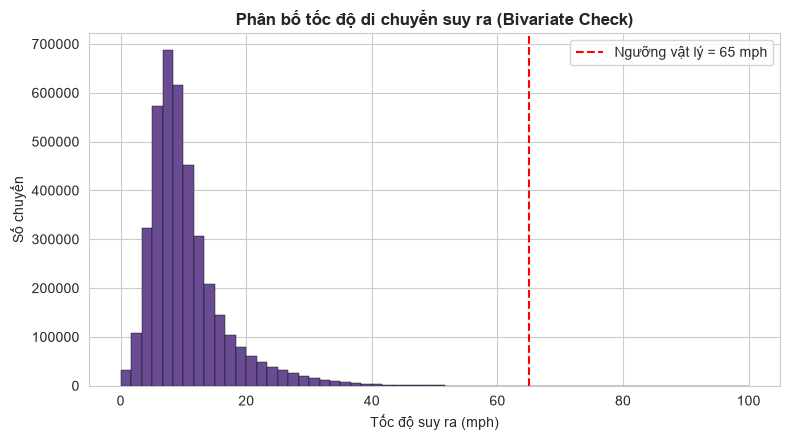

In [20]:
df_speed_check = df.copy()
df_speed_check["trip_duration_min"] = (
    (df_speed_check["tpep_dropoff_datetime"] - df_speed_check["tpep_pickup_datetime"])
    .dt.total_seconds() / 60.0
)
df_speed_check = df_speed_check[
    (df_speed_check["trip_duration_min"] > 0) &
    (df_speed_check["trip_distance"] > 0) &
    (df_speed_check["trip_distance"] < 100)
]
df_speed_check["speed_mph"] = (
    df_speed_check["trip_distance"] / df_speed_check["trip_duration_min"] * 60
)

# Ngưỡng vật lý hợp lý: tốc độ tối đa taxi NYC hiếm khi vượt 65 mph
speed_outliers = df_speed_check[df_speed_check["speed_mph"] > 65]
print(f"Số chuyến có tốc độ suy ra > 65 mph: {len(speed_outliers):,} "
      f"({len(speed_outliers) / len(df_speed_check) * 100:.4f}%)")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df_speed_check[df_speed_check["speed_mph"] < 100]["speed_mph"],
        bins=60, color="#6a4c93", edgecolor="black", linewidth=0.3)
ax.axvline(65, color="red", linestyle="--", linewidth=1.5, label="Ngưỡng vật lý = 65 mph")
ax.set_xlabel("Tốc độ suy ra (mph)")
ax.set_ylabel("Số chuyến")
ax.set_title("Phân bố tốc độ di chuyển suy ra (Bivariate Check)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


**Diễn giải:** Tỷ lệ chuyến vượt ngưỡng tốc độ vật lý hợp lý cho biết mức độ
tồn tại của outlier "ẩn" — những bản ghi lọt qua các bộ lọc `fare_amount`
và `trip_distance` riêng lẻ nhưng thực chất vô lý khi xét kết hợp. Đây là
phát hiện bổ sung quan trọng cho Data Preparation: nếu tỷ lệ này đáng kể,
nên cân nhắc thêm điều kiện lọc `speed_mph <= 65` vào bước Clean Data (mục
2.3), bên cạnh các ngưỡng đơn biến đã có.

### 4.4. Trực quan hóa tổng quan chất lượng dữ liệu

Ba khía cạnh chất lượng đã kiểm tra ở trên — Completeness (null), Uniqueness (trùng lặp), Validity (outlier) — được tổng hợp lại thành một hình duy nhất, giúp có cái nhìn tổng quan trước khi chuyển sang Data Preparation.

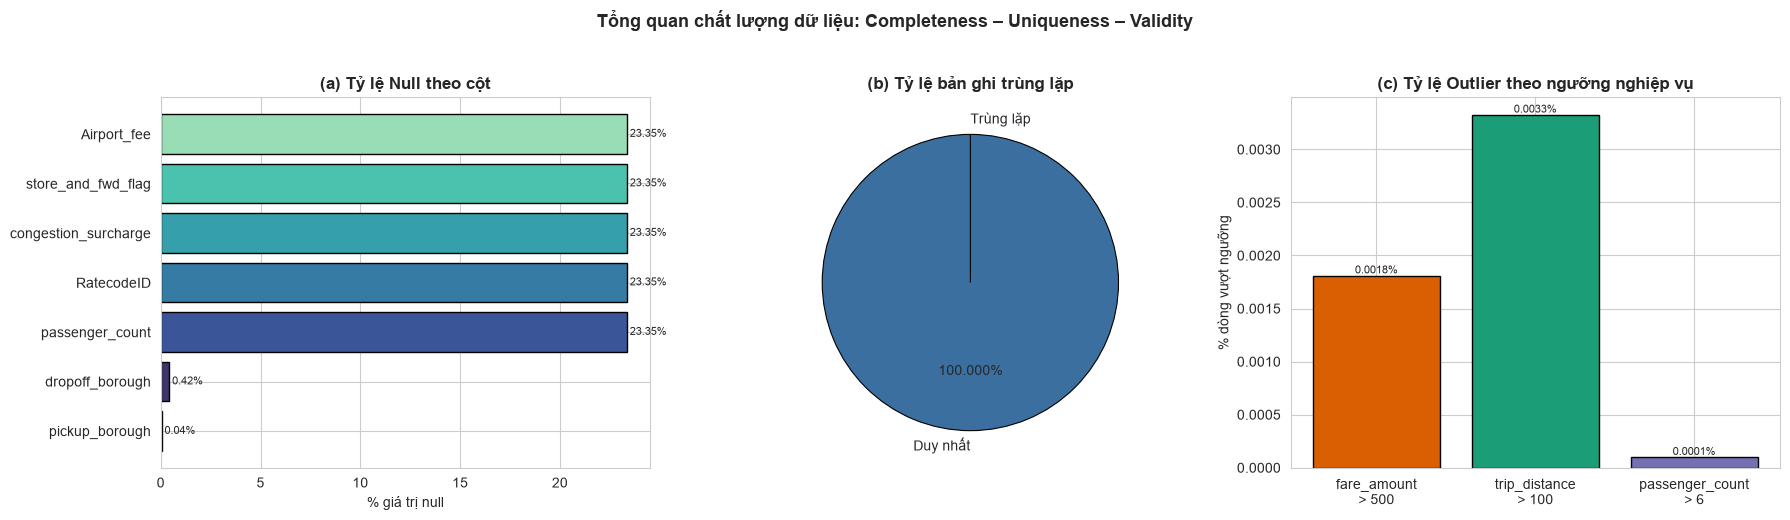

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Tỷ lệ null theo từng cột (chỉ hiển thị cột có null) ---
null_pct_plot = (df.isnull().sum() / len(df) * 100).round(2)
null_pct_plot = null_pct_plot[null_pct_plot > 0].sort_values(ascending=True)

axes[0].barh(null_pct_plot.index, null_pct_plot.values,
             color=sns.color_palette("mako", len(null_pct_plot)), edgecolor="black")
axes[0].set_xlabel("% giá trị null")
axes[0].set_title("(a) Tỷ lệ Null theo cột", fontweight="bold")
for i, v in enumerate(null_pct_plot.values):
    axes[0].text(v, i, f" {v}%", va="center", fontsize=8)

# --- Panel 2: Bản ghi duy nhất vs trùng lặp ---
n_duplicates = df.duplicated().sum()
n_unique = len(df) - n_duplicates
axes[1].pie(
    [n_unique, n_duplicates], labels=["Duy nhất", "Trùng lặp"],
    autopct=lambda p: f"{p:.3f}%" if p > 0 else "",
    colors=["#3b6fa0", "#e34a4a"], startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}
)
axes[1].set_title("(b) Tỷ lệ bản ghi trùng lặp", fontweight="bold")

# --- Panel 3: Tỷ lệ vượt ngưỡng outlier theo từng biến ---
outlier_checks = [("fare_amount", 500), ("trip_distance", 100), ("passenger_count", 6)]
labels = [f"{c}\n> {t}" for c, t in outlier_checks]
pct_over = [(df[c] > t).sum() / len(df) * 100 for c, t in outlier_checks]

bars = axes[2].bar(labels, pct_over, color=["#d95f02", "#1b9e77", "#7570b3"], edgecolor="black")
axes[2].set_ylabel("% dòng vượt ngưỡng")
axes[2].set_title("(c) Tỷ lệ Outlier theo ngưỡng nghiệp vụ", fontweight="bold")
for bar, v in zip(bars, pct_over):
    axes[2].text(bar.get_x() + bar.get_width()/2, v, f"{v:.4f}%",
                 ha="center", va="bottom", fontsize=8)

plt.suptitle("Tổng quan chất lượng dữ liệu: Completeness – Uniqueness – Validity",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()


**Nhận xét:** Cả ba khía cạnh chất lượng đều cho thấy một bức tranh nhất quán — các vấn đề tồn tại (null, trùng lặp, outlier) đều chiếm tỷ trọng rất nhỏ so với quy mô tổng thể của dữ liệu. Điều này củng cố kết luận rằng bộ dữ liệu NYC Yellow Taxi có chất lượng tốt ở phần lõi, và các bước xử lý ở Data Preparation chỉ cần can thiệp có chọn lọc (flag, điền giá trị, loại bỏ theo ngưỡng cụ thể) thay vì phải cắt bỏ một phần lớn dữ liệu.

## Tổng hợp phát hiện (Summary of Findings)

Notebook này thực hiện đầy đủ bốn bước của giai đoạn Data Understanding,
đồng thời mở rộng thêm các phân tích chuyên sâu (mẫu hình di chuyển liên
Borough, kiểm tra outlier đa biến bằng tốc độ) để có căn cứ vững chắc hơn
cho Data Preparation. Các phát hiện chính:

- **Schema** đúng như kỳ vọng, các trường thời gian ở đúng kiểu datetime.
- **Biến phân loại** (`VendorID`, `RatecodeID`, `payment_type`) có phân bố
  lệch về một vài nhóm chiếm đa số, tồn tại giá trị hiếm gặp cần đối chiếu
  Data Dictionary trước khi loại bỏ.
- **Quãng đường & giá cước** đều lệch phải mạnh (Skewness dương), nhất
  quán với nhau — đa số chuyến ngắn, giá thấp.
- **Nhu cầu theo giờ** phân bố không đồng đều (Chi-square bác bỏ $H_0$),
  có đỉnh rõ rệt vào giờ cao điểm.
- **Bất đối xứng hướng di chuyển:** trên toàn bộ dữ liệu, tín hiệu khá yếu
  và nhiễu do bị pha loãng bởi chuyến nội bộ Manhattan (chiếm đa số). Sau
  khi cô lập riêng chuyến liên Borough, mẫu hình commuting hiện ra rất rõ:
  1h-5h sáng nghiêng mạnh về "rời Manhattan" (khả năng do các chuyến ra sân
  bay sớm), 7h-10h sáng đảo chiều mạnh sang "đến Manhattan" (đúng mẫu hình
  đi làm cổ điển, đỉnh tại 9h). Điểm bất ngờ: khung 15h-20h vẫn nghiêng nhẹ
  về "đến" thay vì "rời" như kỳ vọng — giả thuyết là dòng khách giải trí/ăn
  uống buổi tối chồng lấp lên xu hướng về nhà, cần dữ liệu Zone chi tiết
  hơn để xác nhận chắc chắn.
- **Tương quan giữa các biến:** `fare_amount` tương quan mạnh với
  `trip_distance`; `tip_amount` tương quan dương với `fare_amount`;
  `passenger_count` gần như độc lập.
- **Giá trị thiếu:** null tập trung đồng thời ở 5 cột phụ, xác nhận bằng
  cả biểu đồ lẫn kiểm định Chi-square là phụ thuộc vào `VendorID` — một
  trường hợp MNAR có chủ đích ở cấp hệ thống (lỗi/giới hạn feed dữ liệu
  của một vendor cụ thể), không phải missing ngẫu nhiên.
- **Bản ghi trùng lặp:** tồn tại một tỷ lệ nhỏ, cần loại bỏ ở Data
  Preparation.
- **Giá trị bất thường (đơn biến):** `fare_amount`, `trip_distance` có
  phần đuôi vượt ngưỡng IQR nhưng chiếm tỷ lệ cực nhỏ (<0.01%); kiểm tra
  chi tiết xác nhận đây là lỗi ghi nhận (giá trị lặp bất thường, mâu thuẫn
  giữa `RatecodeID` và quãng đường thực tế).
- **Giá trị bất thường (đa biến - tốc độ):** một số chuyến có tốc độ suy
  ra vượt ngưỡng vật lý hợp lý (>65 mph) dù `fare_amount`/`trip_distance`
  riêng lẻ đều nằm trong ngưỡng — outlier "ẩn" chỉ phát hiện được khi xét
  kết hợp hai biến, cần bổ sung điều kiện lọc `speed_mph` ở Data
  Preparation.

**Nhận định chung:** Bộ dữ liệu NYC Yellow Taxi có chất lượng tổng thể khá
tốt — các vấn đề phát hiện được (null, trùng lặp, outlier đơn biến và đa
biến) đều chiếm tỷ trọng nhỏ và có căn cứ rõ ràng để xử lý. Phát hiện đáng
chú ý nhất về mặt nghiệp vụ là sự thiếu vắng mẫu hình commuting rõ rệt —
một giới hạn cần nêu khi diễn giải kết quả Clustering (DM2) ở giai đoạn
Modeling, vì nó cho thấy chiến lược điều phối xe không thể áp dụng máy móc
theo tư duy "giờ cao điểm văn phòng" như với giao thông công cộng. Toàn bộ
phát hiện trên là đầu vào trực tiếp cho notebook **Data Preparation**.